# LSST Time Series Classification
### Adapting Foundation Models: MANTIS · MOMENT · TS2Vec

**Dataset:** LSST (Large Synoptic Survey Telescope) — light curves of astronomical objects  
**Task:** Multi-class classification (14 object types)  
**Models:**
- **MANTIS** — small FM (8M params), contrastive pre-training, classification-specific  
- **MOMENT** — large FM (385M params), masked pre-training, encoder-only  
- **TS2Vec** — self-supervised contrastive SSL, trained *on LSST itself* (no cross-domain transfer)  

Each model is evaluated in two regimes: **zero-shot** (frozen encoder + logistic regression) and **fine-tuned** (trainable head).

## 0. Setup

In [1]:
!pip install -q tslearn
# !pip install -q momentfm
!pip install -q mantis-tsfm
!pip install -q ts2vec
!pip install -q scikit-learn matplotlib seaborn pandas
!pip install peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 147.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 53.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.8/434.8 kB 6.9 MB/s eta 0:00:00


In [2]:
!pip install -q "momentfm" --no-deps
!pip install -q transformers huggingface_hub einops

In [3]:
# ckpt = torch.load('/content/checkpoints/mantis_head.pt')
# print(f"Checkpoint is at epoch: {ckpt['epoch']}")

In [4]:
try:
    import ts2vec
    print('ts2vec already installed')
except ImportError:
    !pip install -q git+https://github.com/zhihanyue/ts2vec.git

!pip install -q scikit-learn matplotlib seaborn pandas

ts2vec already installed


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, balanced_accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from peft import get_peft_model, LoraConfig, TaskType
import torch.nn.functional as F

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT_DIR = '/content/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'Device: {device}')
print(f'Checkpoints will be saved to: {CHECKPOINT_DIR}')

Device: cuda
Checkpoints will be saved to: /content/checkpoints


## 1. Data Loading & Exploration

In [6]:
from tslearn.datasets import UCR_UEA_datasets

ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset('LSST')
# X shape: (n_samples, n_timesteps, n_channels)

print('=== LSST Dataset ===')
print(f'X_train : {X_train.shape}   (samples vs timesteps vs channels)')
print(f'X_test  : {X_test.shape}')
print(f'Classes : {sorted(np.unique(y_train))}  ({len(np.unique(y_train))} total)')

le = LabelEncoder()
y_train_int = le.fit_transform(y_train)
y_test_int  = le.transform(y_test)

NUM_CLASSES = len(le.classes_)
N_CHANNELS  = X_train.shape[2]
SEQ_LEN     = X_train.shape[1]

=== LSST Dataset ===
X_train : (2459, 36, 6)   (samples vs timesteps vs channels)
X_test  : (2466, 36, 6)
Classes : [np.str_('15'), np.str_('16'), np.str_('42'), np.str_('52'), np.str_('53'), np.str_('6'), np.str_('62'), np.str_('64'), np.str_('65'), np.str_('67'), np.str_('88'), np.str_('90'), np.str_('92'), np.str_('95')]  (14 total)


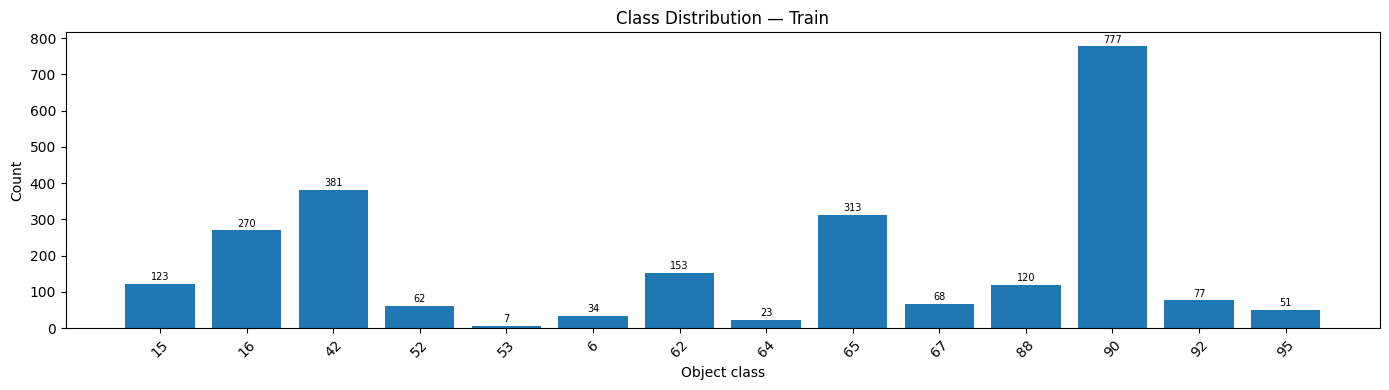

Overall NaN rate: 0.0%


In [7]:
# Class distribution
fig, ax = plt.subplots(figsize=(14, 4))

unique, counts = np.unique(y_train, return_counts=True)
ax.bar(unique, counts)
ax.set_title('Class Distribution — Train', fontsize=12)
ax.set_xlabel('Object class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

for i, (u, c) in enumerate(zip(unique, counts)):
    ax.text(i, c + 5, str(c), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

print(f'Overall NaN rate: {np.isnan(X_train).mean()*100:.1f}%')

In [8]:
unique, counts = np.unique(y_train_int, return_counts=True)
weights = len(y_train_int) / (NUM_CLASSES * counts)
for cls, cnt, w in zip(le.classes_, counts, weights):
    print(f'  class {cls:>6}  count={cnt:>4}  weight={w:.4f}')

  class     15  count= 123  weight=1.4280
  class     16  count= 270  weight=0.6505
  class     42  count= 381  weight=0.4610
  class     52  count=  62  weight=2.8329
  class     53  count=   7  weight=25.0918
  class      6  count=  34  weight=5.1660
  class     62  count= 153  weight=1.1480
  class     64  count=  23  weight=7.6366
  class     65  count= 313  weight=0.5612
  class     67  count=  68  weight=2.5830
  class     88  count= 120  weight=1.4637
  class     90  count= 777  weight=0.2261
  class     92  count=  77  weight=2.2811
  class     95  count=  51  weight=3.4440


## 2. Preprocessing

In [9]:
def impute_linear(X):
    """Linear interpolation of NaNs, per channel per sample.
    np.interp handles boundary NaNs by repeating the nearest valid value."""
    X_out = X.copy()
    for i in range(X_out.shape[0]):
        for c in range(X_out.shape[2]):
            s = X_out[i, :, c]
            nans = np.isnan(s)
            if nans.all():
                s[:] = 0.0
            elif nans.any():
                idx = np.arange(len(s))
                s[nans] = np.interp(idx[nans], idx[~nans], s[~nans])
            X_out[i, :, c] = s
    return X_out

def normalize_per_series(X):
    """Z-score per channel per sample."""
    mean = X.mean(axis=1, keepdims=True)              # (n, 1, c)
    std  = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mean) / std

X_train_prep = normalize_per_series(impute_linear(X_train))
X_test_prep  = normalize_per_series(impute_linear(X_test))

assert np.isnan(X_train_prep).sum() == 0, 'NaNs remain after imputation!'
print('Preprocessing complete.')
print(f'X_train_prep shape: {X_train_prep.shape}')   # (n, 36, 6)

Preprocessing complete.
X_train_prep shape: (2459, 36, 6)


In [10]:
BATCH_SIZE = 32

def make_loader(X_np, y_np, shuffle=False):
    """X_np: (n, T, C) -> tensor (n, C, T). y_np: int array."""
    X_t = torch.FloatTensor(X_np).permute(0, 2, 1)  # (n, C, T)
    y_t = torch.LongTensor(y_np)
    return DataLoader(TensorDataset(X_t, y_t),
                      batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(X_train_prep, y_train_int, shuffle=True)
test_loader  = make_loader(X_test_prep,  y_test_int,  shuffle=False)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')
print(f'Tensor shape per batch: {next(iter(train_loader))[0].shape}  (B, C, T)')

Train batches: 77 | Test batches: 78
Tensor shape per batch: torch.Size([32, 6, 36])  (B, C, T)


## 3. Evaluation Utilities


In [11]:
def compute_ece(probs, labels, n_bins=10):
    """Expected Calibration Error (lower = better calibrated)."""
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    correct      = (predictions == labels).astype(float)
    ece = 0.0
    for b in range(n_bins):
        lo, hi = b / n_bins, (b + 1) / n_bins
        mask = (confidences >= lo) & (confidences < hi)
        if mask.sum() > 0:
            ece += mask.mean() * abs(correct[mask].mean() - confidences[mask].mean())
    return float(ece)

def evaluate(probs, y_true, model_name):
    """Print and return all metrics as a dict."""
    preds = probs.argmax(axis=1)
    row = {
        'Model':        model_name,
        'Macro F1':     f1_score(y_true, preds, average='macro'),
        'Balanced Acc': balanced_accuracy_score(y_true, preds),
        'ECE':          compute_ece(probs, y_true),
    }
    print(f'\n{model_name}')
    for k, v in row.items():
        if k != 'Model':
            print(f'  {k:>15}: {v:.4f}')
    return row

def get_probs_from_model(clf_model, loader):
    """Run a nn.Module classifier over a DataLoader, return softmax probs."""
    clf_model.eval()
    all_probs = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            logits = clf_model(x)
            all_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.concatenate(all_probs)

# Collect all results here
all_results = []

In [12]:
def train_linear_head(train_emb_np, train_labels_np, num_classes,
                      n_epochs=30, lr=1e-3, batch_size=64,
                      checkpoint_name='model', checkpoint_every=5, class_weight=False):
    """
    Train a linear classification head on frozen embeddings.
    Saves a checkpoint every `checkpoint_every` epochs.
    Resumes from checkpoint if one already exists.
    Returns: trained head (nn.Linear), numpy probs on train set.
    """
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'{checkpoint_name}_head.pt')

    X_t = torch.FloatTensor(train_emb_np).to(device)
    y_t = torch.LongTensor(train_labels_np).to(device)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    head = nn.Linear(train_emb_np.shape[1], num_classes).to(device)
    start_epoch = 0

  # checkpoint
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        head.load_state_dict(ckpt['head_state'])
        start_epoch = ckpt['epoch']
        print(f'Resumed {checkpoint_name} from epoch {start_epoch}')

    if start_epoch >= n_epochs:
        print(f'Already trained for {n_epochs} epochs, loading checkpoint.')
        return head

    if class_weight:
        counts     = np.bincount(train_labels_np, minlength=num_classes)
        weights_np = len(train_labels_np) / (num_classes * counts.astype(float))
        weights_t  = torch.FloatTensor(weights_np).to(device)

    optimizer = torch.optim.Adam(head.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(start_epoch, n_epochs):
        head.train()
        total_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(head(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Checkpoint every N epochs
        if (epoch + 1) % checkpoint_every == 0 or (epoch + 1) == n_epochs:
            torch.save({'epoch': epoch + 1, 'head_state': head.state_dict()},
                       ckpt_path)
            print(f'  epoch {epoch+1:>3}/{n_epochs}  '
                  f'loss={total_loss/len(loader):.4f}  [saved]')

    return head


def head_predict_proba(head, emb_np, batch_size=256):
    """Run a trained linear head over embeddings, return softmax probs."""
    head.eval()
    loader = DataLoader(TensorDataset(torch.FloatTensor(emb_np)),
                        batch_size=batch_size)
    probs = []
    with torch.no_grad():
        for (xb,) in loader:
            probs.append(torch.softmax(head(xb.to(device)), dim=-1).cpu().numpy())
    return np.concatenate(probs)

print('Fine-tuning utilities ready.')

Fine-tuning utilities ready.


## MANTIS


In [13]:
from mantis.architecture import Mantis8M
from mantis.trainer import MantisTrainer

In [14]:
mantis_device = 'cuda'

def resize_to_512(X_np):
    """
    Resize LSST 36 to 512
    """

    X_t = torch.tensor(X_np, dtype=torch.float).permute(0, 2, 1)
    return F.interpolate(X_t, size=512, mode='linear', align_corners=False).numpy()

X_train_512 = resize_to_512(X_train_prep)
X_test_512  = resize_to_512(X_test_prep)
print(f'Resized: {X_train_512.shape}')


network = Mantis8M(device=mantis_device)
network = network.from_pretrained("paris-noah/Mantis-8M")
print('MANTIS loaded.')

emb_path_train = os.path.join(CHECKPOINT_DIR, 'mantis_emb_train.npy')
emb_path_test  = os.path.join(CHECKPOINT_DIR, 'mantis_emb_test.npy')

if os.path.exists(emb_path_train):
    print('Loading cached MANTIS embeddings...')
    train_emb_mantis = np.load(emb_path_train)
    test_emb_mantis  = np.load(emb_path_test)
else:
    mantis_extractor = MantisTrainer(device=mantis_device, network=network)
    train_emb_mantis = mantis_extractor.transform(X_train_512)
    test_emb_mantis  = mantis_extractor.transform(X_test_512)
    np.save(emb_path_train, train_emb_mantis)
    np.save(emb_path_test,  test_emb_mantis)
    print(f'  Embeddings saved. Dim: {train_emb_mantis.shape[1]}')

clf_zs = LogisticRegression(max_iter=1000, random_state=SEED)
clf_zs.fit(train_emb_mantis, y_train_int)
probs_mantis_zs = clf_zs.predict_proba(test_emb_mantis)
all_results.append(evaluate(probs_mantis_zs, y_test_int, 'MANTIS: zero-shot'))

#############################
mantis_head = train_linear_head(
    train_emb_mantis, y_train_int, NUM_CLASSES,
    n_epochs=70, checkpoint_name='mantis', checkpoint_every=5
)
probs_mantis_ft = head_predict_proba(mantis_head, test_emb_mantis)
all_results.append(evaluate(probs_mantis_ft, y_test_int, 'MANTIS: fine-tuned'))

Resized: (2459, 6, 512)


config.json:   0%|          | 0.00/335 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/32.5M [00:00<?, ?B/s]

MANTIS loaded.
  Embeddings saved. Dim: 1536

MANTIS: zero-shot
         Macro F1: 0.4434
     Balanced Acc: 0.4240
              ECE: 0.3355
  epoch   5/70  loss=0.6290  [saved]
  epoch  10/70  loss=0.3745  [saved]
  epoch  15/70  loss=0.2862  [saved]
  epoch  20/70  loss=0.2393  [saved]
  epoch  25/70  loss=0.1967  [saved]
  epoch  30/70  loss=0.1616  [saved]
  epoch  35/70  loss=0.1326  [saved]
  epoch  40/70  loss=0.1182  [saved]
  epoch  45/70  loss=0.0996  [saved]
  epoch  50/70  loss=0.0927  [saved]
  epoch  55/70  loss=0.0855  [saved]
  epoch  60/70  loss=0.0695  [saved]
  epoch  65/70  loss=0.0632  [saved]
  epoch  70/70  loss=0.0573  [saved]

MANTIS: fine-tuned
         Macro F1: 0.4488
     Balanced Acc: 0.4302
              ECE: 0.2993


## MANTIS with class weighting

In [15]:
for f in ['mantis_emb_train_weight.npy', 'mantis_emb_test_weight.npy', 'mantis_finetuned.pt']:
    path = os.path.join(CHECKPOINT_DIR, f)
    if os.path.exists(path):
        os.remove(path)
        print(f'Deleted {f}')

In [16]:
ckpt = torch.load('/content/checkpoints/mantis_head.pt')
print(ckpt['epoch'])

70


In [17]:
def resize_to_512(X_np):
    """
    Resize LSST 36 to 512
    """

    X_t = torch.tensor(X_np, dtype=torch.float).permute(0, 2, 1)
    return F.interpolate(X_t, size=512, mode='linear', align_corners=False).numpy()

X_train_512 = resize_to_512(X_train_prep)
X_test_512  = resize_to_512(X_test_prep)
print(f'Resized: {X_train_512.shape}')


network = Mantis8M(device=mantis_device)
network = network.from_pretrained("paris-noah/Mantis-8M")
print('MANTIS loaded.')


emb_path_train_weight = os.path.join(CHECKPOINT_DIR, 'mantis_emb_train_weight.npy')
emb_path_test_weight  = os.path.join(CHECKPOINT_DIR, 'mantis_emb_test_weight.npy')

if os.path.exists(emb_path_train_weight):
    print('Loading cached MANTIS embeddings...')
    train_emb_mantis = np.load(emb_path_train_weight)
    test_emb_mantis  = np.load(emb_path_test_weight)
else:
    mantis_extractor = MantisTrainer(device=mantis_device, network=network)
    train_emb_mantis = mantis_extractor.transform(X_train_512)
    test_emb_mantis  = mantis_extractor.transform(X_test_512)
    np.save(emb_path_train_weight, train_emb_mantis)
    np.save(emb_path_test_weight,  test_emb_mantis)
    print(f'  Embeddings saved. Dim: {train_emb_mantis.shape[1]}')

clf_zs = LogisticRegression(max_iter=1000, random_state=SEED)
clf_zs.fit(train_emb_mantis, y_train_int)
probs_mantis_zs = clf_zs.predict_proba(test_emb_mantis)
all_results.append(evaluate(probs_mantis_zs, y_test_int, 'MANTIS: zero-shot'))


mantis_head = train_linear_head(
    train_emb_mantis, y_train_int, NUM_CLASSES,
    n_epochs=70, checkpoint_name='mantis', checkpoint_every=5, class_weight=True
)
probs_mantis_ft = head_predict_proba(mantis_head, test_emb_mantis)
all_results.append(evaluate(probs_mantis_ft, y_test_int, 'MANTIS: fine-tuned'))

Resized: (2459, 6, 512)


MANTIS loaded.
  Embeddings saved. Dim: 1536

MANTIS: zero-shot
         Macro F1: 0.4434
     Balanced Acc: 0.4240
              ECE: 0.3355
Resumed mantis from epoch 70
Already trained for 70 epochs, loading checkpoint.

MANTIS: fine-tuned
         Macro F1: 0.4488
     Balanced Acc: 0.4302
              ECE: 0.2993


In [18]:
mantis_ft_ckpt = os.path.join(CHECKPOINT_DIR, 'mantis_finetuned')

mantis_ft = MantisTrainer(device=mantis_device, network=network)

# fit() fine-tunes the full model — encoder weights update, not just the head
# This is the real "adapt a foundation model" step
mantis_ft.fit(X_train_512, y_train_int)

Epoch 499: Train Loss 0.0003: 100%|██████████| 500/500 [10:54<00:00,  1.31s/it]


FineTuningNetwork(
  (encoder): Mantis8M(
    (tokgen_unit): TokenGeneratorUnit(
      (convs): ModuleList(
        (0-1): 2 x Convolution(
          (conv): Conv1d(1, 256, kernel_size=(17,), stride=(1,), padding=(8,))
        )
      )
      (layer_norms): ModuleList(
        (0-1): 2 x LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      )
      (scalar_encoders): ModuleList(
        (0-1): 2 x MultiScaledScalarEncoder(
          (encoders): ModuleList(
            (0-8): 9 x ScalarEncoder(
              (layer_norm): LayerNorm((32,), eps=1e-15, elementwise_affine=True)
            )
          )
        )
      )
      (linear_encoder): LinearEncoder(
        (linear): Linear(in_features=576, out_features=256, bias=True)
        (layer_norm): LayerNorm((256,), eps=1e-15, elementwise_affine=True)
      )
    )
    (vit_unit): ViTUnit(
      (pos_encoder): PositionalEncoding(
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (transformer): Transformer(
        (laye

In [19]:
probs_mantis_ft = mantis_ft.predict_proba(X_test_512)
all_results.append(evaluate(probs_mantis_ft, y_test_int, 'MANTIS fine-tuned (full)'))


MANTIS fine-tuned (full)
         Macro F1: 0.4704
     Balanced Acc: 0.4471
              ECE: 0.2355


## LoRA and linear probe

In [20]:
print('Linear layers in MANTIS:\n')
for name, module in network.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(f'  {name:60s}  in={module.in_features}, out={module.out_features}')

Linear layers in MANTIS:

  tokgen_unit.linear_encoder.linear                             in=576, out=256
  vit_unit.transformer.layers.0.0.fn.to_qkv                     in=256, out=3072
  vit_unit.transformer.layers.0.0.fn.to_out.0                   in=1024, out=256
  vit_unit.transformer.layers.0.1.fn.net.0                      in=256, out=512
  vit_unit.transformer.layers.0.1.fn.net.3                      in=512, out=256
  vit_unit.transformer.layers.1.0.fn.to_qkv                     in=256, out=3072
  vit_unit.transformer.layers.1.0.fn.to_out.0                   in=1024, out=256
  vit_unit.transformer.layers.1.1.fn.net.0                      in=256, out=512
  vit_unit.transformer.layers.1.1.fn.net.3                      in=512, out=256
  vit_unit.transformer.layers.2.0.fn.to_qkv                     in=256, out=3072
  vit_unit.transformer.layers.2.0.fn.to_out.0                   in=1024, out=256
  vit_unit.transformer.layers.2.1.fn.net.0                      in=256, out=512
  vit_un

In [21]:
LORA_CKPT  = os.path.join(CHECKPOINT_DIR, 'mantis_lora.pt')
HEAD_CKPT  = os.path.join(CHECKPOINT_DIR, 'mantis_head.pt')
LORA_EPOCHS = 30 # 50 is too much...
LORA_LR     = 5e-5


lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias='none',
    target_modules=['to_qkv'],
)


network_lora = Mantis8M(device=mantis_device)
network_lora = network_lora.from_pretrained("paris-noah/Mantis-8M")
network_lora = get_peft_model(network_lora, lora_config)
network_lora.print_trainable_parameters()


head_lora = torch.nn.Linear(1536, NUM_CLASSES).to(device)

ckpt = torch.load(HEAD_CKPT, map_location=device)
head_lora.load_state_dict(ckpt['head_state'])


trainable_params = list(network_lora.parameters()) + list(head_lora.parameters())
optimizer = torch.optim.Adam(trainable_params, lr=LORA_LR)

counts     = np.bincount(y_train_int, minlength=NUM_CLASSES)
weights_np = len(y_train_int) / (NUM_CLASSES * counts.astype(float))
weights_t  = torch.FloatTensor(weights_np).to(device)
criterion  = torch.nn.CrossEntropyLoss(weight=weights_t)

start_epoch = 0
if os.path.exists(LORA_CKPT):
    ckpt = torch.load(LORA_CKPT, map_location=device)
    network_lora.load_state_dict(ckpt['lora_state'])
    head_lora.load_state_dict(ckpt['head_state'])
    start_epoch = ckpt['epoch']
    print(f'Resumed LoRA from epoch {start_epoch}')


mantis_trainer_lora = MantisTrainer(device=mantis_device, network=network_lora)

if start_epoch < LORA_EPOCHS:
    for epoch in range(start_epoch, LORA_EPOCHS):
        network_lora.train()
        head_lora.train()
        total_loss = 0.0

        for x, y in DataLoader(
                TensorDataset(torch.FloatTensor(X_train_512), torch.LongTensor(y_train_int)),
                batch_size=BATCH_SIZE, shuffle=True):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            # Extract embeddings through LoRA-wrapped encoder
            emb  = torch.FloatTensor(
                mantis_trainer_lora.transform(x.cpu().numpy())
            ).to(device)
            loss = criterion(head_lora(emb), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 5 == 0 or (epoch + 1) == LORA_EPOCHS:
            torch.save({
                'epoch'      : epoch + 1,
                'lora_state' : network_lora.state_dict(),
                'head_state' : head_lora.state_dict(),
            }, LORA_CKPT)
            print(f'  epoch {epoch+1:>3}/{LORA_EPOCHS}  '
                  f'loss={total_loss/len(train_loader):.4f}  [saved]')



network_lora.eval()
head_lora.eval()

test_emb_lora = torch.FloatTensor(
    mantis_trainer_lora.transform(X_test_512)
).to(device)



trainable params: 159,744 || all params: 8,263,680 || trainable%: 1.9331
  epoch   5/30  loss=0.0223  [saved]
  epoch  10/30  loss=0.0219  [saved]
  epoch  15/30  loss=0.0211  [saved]
  epoch  20/30  loss=0.0204  [saved]
  epoch  25/30  loss=0.0201  [saved]
  epoch  30/30  loss=0.0196  [saved]


In [22]:
with torch.no_grad():
    probs_lora = torch.softmax(head_lora(test_emb_lora), dim=-1).cpu().numpy()

all_results.append(evaluate(probs_lora, y_test_int, 'MANTIS: LoRA (warm start)'))


MANTIS: LoRA (warm start)
         Macro F1: 0.4582
     Balanced Acc: 0.4453
              ECE: 0.3135


MANTIS: zero-shot
         Macro F1: 0.4266
     Balanced Acc: 0.4086
              ECE: 0.3370
  epoch   5/70  loss=0.5963  [saved]
  epoch  10/70  loss=0.3919  [saved]
  epoch  15/70  loss=0.2952  [saved]
  epoch  20/70  loss=0.2363  [saved]
  epoch  25/70  loss=0.2452  [saved]
  epoch  30/70  loss=0.1575  [saved]
  epoch  35/70  loss=0.1370  [saved]
  epoch  40/70  loss=0.1251  [saved]
  epoch  45/70  loss=0.1108  [saved]
  epoch  50/70  loss=0.0917  [saved]
  epoch  55/70  loss=0.0934  [saved]
  epoch  60/70  loss=0.0702  [saved]
  epoch  65/70  loss=0.0644  [saved]
  epoch  70/70  loss=0.0579  [saved]

MANTIS: fine-tuned
         Macro F1: 0.4553
     Balanced Acc: 0.4381
              ECE: 0.3091




MANTIS: LoRA (warm start)
         Macro F1: 0.4659
     Balanced Acc: 0.4549
              ECE: 0.3138


barely any improvement

## MOMENT

In [23]:
from momentfm import MOMENTPipeline
train_loader_512 = DataLoader(
    TensorDataset(torch.FloatTensor(X_train_512), torch.LongTensor(y_train_int)),
    batch_size=BATCH_SIZE, shuffle=False)
test_loader_512 = DataLoader(
    TensorDataset(torch.FloatTensor(X_test_512), torch.LongTensor(y_test_int)),
    batch_size=BATCH_SIZE, shuffle=False)

In [24]:
moment_enc = MOMENTPipeline.from_pretrained(
    'AutonLab/MOMENT-1-large',
    model_kwargs={'task_name': 'embedding'},
)
moment_enc.init()
moment_enc = moment_enc.to(device)
moment_enc.eval()
print('MOMENT loaded.')

emb_path_mo_train = os.path.join(CHECKPOINT_DIR, 'moment_emb_train.npy')
emb_path_mo_test  = os.path.join(CHECKPOINT_DIR, 'moment_emb_test.npy')

if os.path.exists(emb_path_mo_train):
    print('Loading cached MOMENT embeddings...')
    train_emb_moment = np.load(emb_path_mo_train)
    test_emb_moment  = np.load(emb_path_mo_test)
else:
    def extract_moment_embs(loader):
        embs = []
        with torch.no_grad():
            for x, _ in loader:
                out = moment_enc(x_enc=x.to(device))
                emb = out.embeddings if out.embeddings is not None else out.reconstruction
                embs.append(emb.cpu().numpy())
        return np.concatenate(embs)

    train_emb_moment = extract_moment_embs(train_loader_512)
    test_emb_moment  = extract_moment_embs(test_loader_512)
    np.save(emb_path_mo_train, train_emb_moment)
    np.save(emb_path_mo_test,  test_emb_moment)
    print(f'  Saved. Dim: {train_emb_moment.shape[1]}')

clf_m_zs = LogisticRegression(max_iter=1000, random_state=SEED)
clf_m_zs.fit(train_emb_moment, y_train_int)
probs_moment_zs = clf_m_zs.predict_proba(test_emb_moment)
all_results.append(evaluate(probs_moment_zs, y_test_int, 'MOMENT: zero-shot'))

config.json:   0%|          | 0.00/951 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

MOMENT loaded.
  Saved. Dim: 1024

MOMENT: zero-shot
         Macro F1: 0.2753
     Balanced Acc: 0.2838
              ECE: 0.1160


In [25]:
emb_path_mo_train = os.path.join(CHECKPOINT_DIR, 'moment_emb_train.npy')
emb_path_mo_test  = os.path.join(CHECKPOINT_DIR, 'moment_emb_test.npy')

if os.path.exists(emb_path_mo_train):
    print('Loading cached MOMENT embeddings')
    train_emb_moment = np.load(emb_path_mo_train)
    test_emb_moment  = np.load(emb_path_mo_test)
else:
    def extract_moment_embs(loader):
        embs = []
        with torch.no_grad():
            for x, _ in loader:
                embs.append(moment_enc(x_enc=x.to(device)).embeddings.cpu().numpy())
        return np.concatenate(embs)

    train_emb_moment = extract_moment_embs(train_loader)
    test_emb_moment  = extract_moment_embs(test_loader)
    np.save(emb_path_mo_train, train_emb_moment)
    np.save(emb_path_mo_test,  test_emb_moment)
    print(f'  Saved. Dim: {train_emb_moment.shape[1]}')

clf_m_zs = LogisticRegression(max_iter=1000, random_state=SEED)
clf_m_zs.fit(train_emb_moment, y_train_int)
probs_moment_zs = clf_m_zs.predict_proba(test_emb_moment)
all_results.append(evaluate(probs_moment_zs, y_test_int, 'MOMENT: zero-shot'))

Loading cached MOMENT embeddings

MOMENT: zero-shot
         Macro F1: 0.2753
     Balanced Acc: 0.2838
              ECE: 0.1160


In [26]:
moment_head = train_linear_head(
    train_emb_moment, y_train_int, NUM_CLASSES,
    n_epochs=30, checkpoint_name='moment', checkpoint_every=5
)
probs_moment_ft = head_predict_proba(moment_head, test_emb_moment)
all_results.append(evaluate(probs_moment_ft, y_test_int, 'MOMENT: fine-tuned'))

  epoch   5/30  loss=1.8638  [saved]
  epoch  10/30  loss=1.7123  [saved]
  epoch  15/30  loss=1.6229  [saved]
  epoch  20/30  loss=1.5577  [saved]
  epoch  25/30  loss=1.5170  [saved]
  epoch  30/30  loss=1.4763  [saved]

MOMENT: fine-tuned
         Macro F1: 0.2667
     Balanced Acc: 0.2747
              ECE: 0.1144


## TS2Vec


In [27]:
from ts2vec import TS2Vec

ts2vec_ckpt = os.path.join(CHECKPOINT_DIR, 'ts2vec_model.pkl')

if os.path.exists(ts2vec_ckpt):
    print('Loading saved TS2Vec model...')
    ts2vec_model = joblib.load(ts2vec_ckpt)
else:
    ts2vec_model = TS2Vec(
        input_dims=N_CHANNELS,
        output_dims=320,
        hidden_dims=64,
        depth=10,
        device=0 if torch.cuda.is_available() else 'cpu',
    )
    print('Training TS2Vec...')
    ts2vec_model.fit(X_train_prep, n_epochs=50, verbose=True)
    joblib.dump(ts2vec_model, ts2vec_ckpt)
    print(f'  Saved to {ts2vec_ckpt}')

Training TS2Vec...
Epoch #0: loss=2.2108997542873707
Epoch #1: loss=1.396759837671043
Epoch #2: loss=1.2833389437276554
Epoch #3: loss=1.1220363713557424
Epoch #4: loss=1.0036379375488929
Epoch #5: loss=0.8914403282349406
Epoch #6: loss=0.891437318979525
Epoch #7: loss=0.890726729156145
Epoch #8: loss=0.8327719489343806
Epoch #9: loss=0.79457609365189
Epoch #10: loss=0.866998485685174
Epoch #11: loss=0.7306123383684096
Epoch #12: loss=0.7674920033006107
Epoch #13: loss=0.7383464278738483
Epoch #14: loss=0.7077602385695464
Epoch #15: loss=0.7305584471989301
Epoch #16: loss=0.7292306561485614
Epoch #17: loss=0.725577666284212
Epoch #18: loss=0.6255933192430758
Epoch #19: loss=0.6834104255913129
Epoch #20: loss=0.6683146328318352
Epoch #21: loss=0.6609691131153917
Epoch #22: loss=0.6703324231252171
Epoch #23: loss=0.6294084921771405
Epoch #24: loss=0.6616769840125165
Epoch #25: loss=0.6411217594263601
Epoch #26: loss=0.654500322599037
Epoch #27: loss=0.6384594061600617
Epoch #28: loss=0.5

In [28]:
train_repr = ts2vec_model.encode(X_train_prep, encoding_window='full_series')
test_repr  = ts2vec_model.encode(X_test_prep,  encoding_window='full_series')
print(f'TS2Vec embedding shape: {train_repr.shape}')

clf_ts = LogisticRegression(max_iter=1000, random_state=SEED)
clf_ts.fit(train_repr, y_train_int)
probs_ts2vec = clf_ts.predict_proba(test_repr)
all_results.append(evaluate(probs_ts2vec, y_test_int, 'TS2Vec: linear probe (in-domain SSL)'))


TS2Vec embedding shape: (2459, 320)

TS2Vec: linear probe (in-domain SSL)
         Macro F1: 0.3627
     Balanced Acc: 0.3598
              ECE: 0.0252


## 7. Final Comparison

In [29]:
results_df = pd.DataFrame(all_results).set_index('Model')

print('\n' + '═'*55)
print('           FINAL RESULTS — LSST Classification')
print('═'*55)
print(results_df.round(4).to_string())
print('─'*55)
print('Macro F1 / Balanced Acc : higher is better')
print('ECE                     : lower  is better')


═══════════════════════════════════════════════════════
           FINAL RESULTS — LSST Classification
═══════════════════════════════════════════════════════
                                      Macro F1  Balanced Acc     ECE
Model                                                               
MANTIS: zero-shot                       0.4434        0.4240  0.3355
MANTIS: fine-tuned                      0.4488        0.4302  0.2993
MANTIS: zero-shot                       0.4434        0.4240  0.3355
MANTIS: fine-tuned                      0.4488        0.4302  0.2993
MANTIS fine-tuned (full)                0.4704        0.4471  0.2355
MANTIS: LoRA (warm start)               0.4582        0.4453  0.3135
MOMENT: zero-shot                       0.2753        0.2838  0.1160
MOMENT: zero-shot                       0.2753        0.2838  0.1160
MOMENT: fine-tuned                      0.2667        0.2747  0.1144
TS2Vec: linear probe (in-domain SSL)    0.3627        0.3598  0.0252
────────────

# New experiments
MiniRocket, InceptionTime, PatchTST

In [30]:
!pip install -q aeon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 61.0 MB/s eta 0:00:00


In [31]:
X_train_aeon = X_train_prep.transpose(0, 2, 1).astype(np.float32)  # (n, 6, 36)
X_test_aeon  = X_test_prep.transpose(0, 2, 1).astype(np.float32)

print(f'Aeon input shape: {X_train_aeon.shape}  (samples, channels, timesteps)')

Aeon input shape: (2459, 6, 36)  (samples, channels, timesteps)


### **Rocket**

In [32]:
from aeon.classification.convolution_based import MiniRocketClassifier

minirocket_ckpt = os.path.join(CHECKPOINT_DIR, 'minirocket.pkl')

if os.path.exists(minirocket_ckpt):
    print('Loading saved MiniRocket...')
    minirocket = joblib.load(minirocket_ckpt)
else:
    minirocket = MiniRocketClassifier(random_state=SEED)
    print('Fitting MiniRocket...')
    minirocket.fit(X_train_aeon, y_train_int)
    joblib.dump(minirocket, minirocket_ckpt)
    print('  MiniRocket saved.')

probs_minirocket = minirocket.predict_proba(X_test_aeon)
all_results.append(evaluate(probs_minirocket, y_test_int, 'MiniRocket'))

Fitting MiniRocket...
  MiniRocket saved.

MiniRocket
         Macro F1: 0.3282
     Balanced Acc: 0.3239
              ECE: 0.0000


### InceptionTime

In [33]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [34]:
from aeon.classification.deep_learning import InceptionTimeClassifier

inception_ckpt = os.path.join(CHECKPOINT_DIR, 'inceptiontime.pkl')

import tensorflow

if os.path.exists(inception_ckpt):
    print('Loading saved InceptionTime...')
    inception = joblib.load(inception_ckpt)
else:
    # Then immediately retry
    inception = InceptionTimeClassifier(
        n_epochs=50,
        batch_size=32,
        random_state=SEED,
        verbose=True,
    )
    inception.fit(X_train_aeon, y_train_int)

probs_inception = inception.predict_proba(X_test_aeon)
all_results.append(evaluate(probs_inception, y_test_int, 'InceptionTime'))

InternalError: {{function_node __wrapped__Cast_device_/job:localhost/replica:0/task:0/device:GPU:0}} 'cuLaunchKernel(function, gridX, gridY, gridZ, blockX, blockY, blockZ, 0, reinterpret_cast<CUstream>(stream), params, nullptr)' failed with 'CUDA_ERROR_INVALID_HANDLE' [Op:Cast] name: 

### PatchTST

In [35]:
import itertools
from transformers import PatchTSTConfig, PatchTSTForClassification

SEARCH_EPOCHS  = 25
SEARCH_CSV     = os.path.join(CHECKPOINT_DIR, 'patchtst_search.csv')
SEARCH_CKPT    = os.path.join(CHECKPOINT_DIR, 'patchtst_search_state.pt')

grid = {
    'patch_length'      : [4, 8],
    'd_model'           : [64, 128, 256],
    'num_hidden_layers' : [2, 4],
    'lr'                : [1e-4, 5e-4, 1e-3],
}

# Build all combinations
keys   = list(grid.keys())
combos = [dict(zip(keys, v)) for v in itertools.product(*grid.values())]
print(f'Total configs: {len(combos)} vs {SEARCH_EPOCHS} epochs\n')

# Load already-completed results if resuming
if os.path.exists(SEARCH_CSV):
    search_df    = pd.read_csv(SEARCH_CSV)
    done_configs = set(search_df['config_id'].tolist())
    print(f'Resuming: {len(done_configs)}/{len(combos)} configs already done.')
else:
    search_df    = pd.DataFrame()
    done_configs = set()

def make_patchtst(cfg):
    """Instantiate a PatchTST model from a hyperparameter dict."""
    patch_len = cfg['patch_length']
    stride    = patch_len // 2          # 50% overlap — best per paper
    # num_attention_heads must divide d_model
    heads     = 4 if cfg['d_model'] >= 64 else 2

    config = PatchTSTConfig(
        num_input_channels  = N_CHANNELS,
        context_length      = SEQ_LEN,
        patch_length        = patch_len,
        stride              = stride,
        num_targets         = NUM_CLASSES,
        d_model             = cfg['d_model'],
        num_attention_heads = heads,
        num_hidden_layers   = cfg['num_hidden_layers'],
        ffn_dim             = cfg['d_model'] * 2,
        dropout             = 0.1,
        head_dropout        = 0.1,
    )
    return PatchTSTForClassification(config).to(device)


for i, cfg in enumerate(combos):
    config_id = i

    if config_id in done_configs:
        continue

    print(f'[{i+1:>2}/{len(combos)}] {cfg}')

    model     = make_patchtst(cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    criterion = nn.CrossEntropyLoss()

    for epoch in range(SEARCH_EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out  = model(past_values=x.permute(0, 2, 1))
            loss = criterion(out.prediction_logits, y)
            loss.backward()
            optimizer.step()

    # Evaluate on test set
    model.eval()
    all_probs = []
    with torch.no_grad():
        for x, _ in test_loader:
            out = model(past_values=x.permute(0, 2, 1).to(device))
            all_probs.append(torch.softmax(out.prediction_logits, dim=-1).cpu().numpy())

    probs = np.concatenate(all_probs)
    preds = probs.argmax(axis=1)
    row   = {
        'config_id'         : config_id,
        'patch_length'      : cfg['patch_length'],
        'd_model'           : cfg['d_model'],
        'num_hidden_layers' : cfg['num_hidden_layers'],
        'lr'                : cfg['lr'],
        'macro_f1'          : f1_score(y_test_int, preds, average='macro'),
        'balanced_acc'      : balanced_accuracy_score(y_test_int, preds),
        'ece'               : compute_ece(probs, y_test_int),
    }
    print(f' F1={row["macro_f1"]:.4f}  BalAcc={row["balanced_acc"]:.4f}  ECE={row["ece"]:.4f}')

    # Append and save immediately — safe against Colab crashes
    search_df = pd.concat([search_df, pd.DataFrame([row])], ignore_index=True)
    search_df.to_csv(SEARCH_CSV, index=False)

    del model
    torch.cuda.empty_cache()


print('\n' + '═'*70)
print('PATCHTST SEARCH — TOP 10 by Macro F1')
print('═'*70)
top10 = search_df.sort_values('macro_f1', ascending=False).head(10)
print(top10[['patch_length','d_model','num_hidden_layers','lr',
             'macro_f1','balanced_acc','ece']].to_string(index=False))

best = search_df.loc[search_df['macro_f1'].idxmax()]
print(f'\nBest config:')
print(f'  patch_length={int(best.patch_length)}, d_model={int(best.d_model)}, '
      f'layers={int(best.num_hidden_layers)}, lr={best.lr}')
print(f'  Macro F1={best.macro_f1:.4f}  BalAcc={best.balanced_acc:.4f}  ECE={best.ece:.4f}')

Total configs: 36 vs 25 epochs

[ 1/36] {'patch_length': 4, 'd_model': 64, 'num_hidden_layers': 2, 'lr': 0.0001}
 F1=0.3358  BalAcc=0.3436  ECE=0.0302
[ 2/36] {'patch_length': 4, 'd_model': 64, 'num_hidden_layers': 2, 'lr': 0.0005}
 F1=0.3726  BalAcc=0.3801  ECE=0.0359
[ 3/36] {'patch_length': 4, 'd_model': 64, 'num_hidden_layers': 2, 'lr': 0.001}
 F1=0.3713  BalAcc=0.3712  ECE=0.0731
[ 4/36] {'patch_length': 4, 'd_model': 64, 'num_hidden_layers': 4, 'lr': 0.0001}
 F1=0.3549  BalAcc=0.3559  ECE=0.0326
[ 5/36] {'patch_length': 4, 'd_model': 64, 'num_hidden_layers': 4, 'lr': 0.0005}
 F1=0.4057  BalAcc=0.3941  ECE=0.0668
[ 6/36] {'patch_length': 4, 'd_model': 64, 'num_hidden_layers': 4, 'lr': 0.001}
 F1=0.4058  BalAcc=0.3991  ECE=0.0443
[ 7/36] {'patch_length': 4, 'd_model': 128, 'num_hidden_layers': 2, 'lr': 0.0001}
 F1=0.3696  BalAcc=0.3786  ECE=0.0535
[ 8/36] {'patch_length': 4, 'd_model': 128, 'num_hidden_layers': 2, 'lr': 0.0005}
 F1=0.4206  BalAcc=0.4199  ECE=0.0815
[ 9/36] {'patch_

In [36]:
best_cfg = {
    'patch_length'      : int(best.patch_length),
    'd_model'           : int(best.d_model),
    'num_hidden_layers' : int(best.num_hidden_layers),
    'lr'                : float(best.lr),
}
print(f'Retraining best config: {best_cfg}')

patchtst_final_ckpt = os.path.join(CHECKPOINT_DIR, 'patchtst_final.pt')
FINAL_EPOCHS        = 100

patchtst_best = make_patchtst(best_cfg)
start_epoch   = 0

if os.path.exists(patchtst_final_ckpt):
    ckpt = torch.load(patchtst_final_ckpt, map_location=device)
    patchtst_best.load_state_dict(ckpt['model_state'])
    start_epoch = ckpt['epoch']
    print(f'Resumed from epoch {start_epoch}')

if start_epoch < FINAL_EPOCHS:
    optimizer = torch.optim.Adam(patchtst_best.parameters(), lr=best_cfg['lr'])
    criterion = nn.CrossEntropyLoss()

    for epoch in range(start_epoch, FINAL_EPOCHS):
        patchtst_best.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out  = patchtst_best(past_values=x.permute(0, 2, 1))
            loss = criterion(out.prediction_logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 10 == 0 or (epoch + 1) == FINAL_EPOCHS:
            torch.save({'epoch': epoch + 1,
                        'model_state': patchtst_best.state_dict()},
                       patchtst_final_ckpt)
            print(f'  epoch {epoch+1:>3}/{FINAL_EPOCHS}  '
                  f'loss={total_loss/len(train_loader):.4f}  [saved]')

patchtst_best.eval()
all_probs = []
with torch.no_grad():
    for x, _ in test_loader:
        out = patchtst_best(past_values=x.permute(0, 2, 1).to(device))
        all_probs.append(torch.softmax(out.prediction_logits, dim=-1).cpu().numpy())

probs_patchtst = np.concatenate(all_probs)
all_results.append(evaluate(probs_patchtst, y_test_int, 'PatchTST (best config, 200ep)'))

Retraining best config: {'patch_length': 4, 'd_model': 256, 'num_hidden_layers': 4, 'lr': 0.0001}
  epoch  10/100  loss=0.9432  [saved]
  epoch  20/100  loss=0.6327  [saved]
  epoch  30/100  loss=0.3164  [saved]
  epoch  40/100  loss=0.2242  [saved]
  epoch  50/100  loss=0.0999  [saved]
  epoch  60/100  loss=0.0035  [saved]
  epoch  70/100  loss=0.6612  [saved]
  epoch  80/100  loss=0.0128  [saved]
  epoch  90/100  loss=0.0204  [saved]
  epoch 100/100  loss=0.2895  [saved]

PatchTST (best config, 200ep)
         Macro F1: 0.4239
     Balanced Acc: 0.4169
              ECE: 0.3007
